**AB Test summary:**
Please go directly to the last section of this notebook: Conclusion & Recommendation.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

from bigquery import run_query
from scipy import stats
from scipy.stats import chisquare

# Data Load


- need ab test data at user level
- need engagement data of users who were active before and during the ab test, retention?

In [11]:
ab_user_level_sql = """
with 
  segment as (
SELECT 
  a.playerid, 
  DATE(a.activity_date) as activity_date,
  a.gameends, a.purchases, r.abtest_group,
  DATE(r.conversion_date) as first_purchase_date,
  DATE(r.install_date) as install_date,
  DATE(r.assignment_date) as abtest_random_date,
  a.gameends as number_game_rounds, 
  a.purchases as number_purchases,
  case when r.install_date = r.assignment_date then "new user" else "existing user" end as player_type,
  case 
    when r.conversion_date is null then "non paying player"
    when r.conversion_date < r.assignment_date then "exising spender"
    when r.conversion_date >= r.assignment_date then "new spender"
    else "NA"
  end as spending_type
FROM `king-ds-recruit-candidate-1114.abtest.activity` a
JOIN `king-ds-recruit-candidate-1114.abtest.assignment` r
  on r.playerid = a.playerid
  )

SELECT
  playerid,
  abtest_group,
  first_purchase_date,
  install_date,
  abtest_random_date,
  player_type,
  spending_type,
  sum(number_game_rounds) as number_game_rounds,
  sum(number_purchases) as number_purchases,
  count(distinct case when number_purchases > 0 then activity_date end) number_playing_days_with_purchase
FROM segment
WHERE activity_date >= abtest_random_date
GROUP BY all
"""
ab_user_level_df = run_query(ab_user_level_sql, save_as= "ab_user_level")

print(ab_user_level_df.head())

   playerid abtest_group first_purchase_date install_date abtest_random_date  \
0  27440309            A                 NaT   2016-10-01         2017-05-04   
1  45857975            B                 NaT   2017-04-01         2017-05-04   
2  50971813            A                 NaT   2017-05-21         2017-05-21   
3  46701591            A                 NaT   2017-04-10         2017-05-04   
4  18156926            A                 NaT   2016-06-30         2017-05-04   

     player_type      spending_type  number_game_rounds  number_purchases  \
0  existing user  non paying player                 129                 0   
1  existing user  non paying player                 104                 0   
2       new user  non paying player                   9                 0   
3  existing user  non paying player                 118                 0   
4  existing user  non paying player                 164                 0   

   number_playing_days_with_purchase  
0                

In [12]:
ab_user_level_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10331056 entries, 0 to 10331055
Data columns (total 10 columns):
 #   Column                             Dtype 
---  ------                             ----- 
 0   playerid                           Int64 
 1   abtest_group                       str   
 2   first_purchase_date                dbdate
 3   install_date                       dbdate
 4   abtest_random_date                 dbdate
 5   player_type                        str   
 6   spending_type                      str   
 7   number_game_rounds                 Int64 
 8   number_purchases                   Int64 
 9   number_playing_days_with_purchase  Int64 
dtypes: Int64(4), dbdate(3), str(3)
memory usage: 1.1 GB


In [ ]:
retention_assignment_date_sql = """
with
  assign as (
SELECT
  r.playerid,
  r.abtest_group,
  DATE(r.assignment_date) as assign_date,
  case when r.install_date = r.assignment_date then "new user" else "existing user" end as player_type,
  case
    when r.conversion_date is null then "non paying player"
    when r.conversion_date < r.assignment_date then "exising spender"
    when r.conversion_date >= r.assignment_date then "new spender"
    else "NA"
  end as spending_type
FROM `king-ds-recruit-candidate-1114.abtest.assignment` r
  )

SELECT
  s.playerid,
  s.abtest_group,
  s.player_type,
  s.spending_type,
  -- retained = active again within 7 days AFTER assignment (one row per player)
  coalesce(logical_or(
    DATE(a.activity_date) > s.assign_date
    and DATE(a.activity_date) <= DATE_ADD(s.assign_date, INTERVAL 7 DAY)
  ), false) as retention_7days
FROM assign s
LEFT JOIN `king-ds-recruit-candidate-1114.abtest.activity` a
  on a.playerid = s.playerid
GROUP BY s.playerid, s.abtest_group, s.player_type, s.spending_type
"""
retention_assignment_date_df = run_query(retention_assignment_date_sql, save_as="retention")

# retention rate per group =
print(retention_assignment_date_df.groupby("abtest_group")["retention_7days"].agg(["size", "mean"]))

# Hypothesis statement

**Game context:**

The game is F2P and ~97% of active players never purchase; revenue comes almost entirely from hint purchases made to get past levels players can't solve. So anything that makes players more reliant on paid hints to progress is a lever on revenue.

**Hypothesis:**

Because hint demand rises when players struggle to progress unaided, we believe the treatment will increase purchases per player vs. control, while not harming the engagement and retention of players.
Formal statement (primary metric = purchases per player, proxy for revenue per user):

- H₀ (null): The new experience has no effect on purchases per player vs. control (B − A = 0).
- H₁ (alternative): The new experience increases purchases per player vs. control (B − A > 0), one-sided.

The treatment is a new playing experience that is harder to pass a level. It can be less free hints or less effective hints or increasing difficulty of math questions. From the data (decrease number of game rounds while increasing the purchase), we can not differentiate what exactly the treatment is. But it clearly indicates an experience of being more difficult to solve a math question/ pass a level.

**Metrics**

1. Primary metric: caped purchases per player: expected to be higher in B
2. Guardrail metrics:
- (uncaped) purchase per player
- game rounds per player: not meaningfully lower in B (a small drop is acceptable; a large one is not).
- 7-day retention: not lower in B (protects long-term player base against frustration/churn).
3. Secondary metrics:
- purchase rate (% buying) 
- average number of purchases per spender: higher in B, confirming the hint-buying mechanism.

Note: due to data limitation that revenue data is not available, so I decide to use a proxy metric - number of purchase per user as primary metric. In reality, when revenue data is available, the primary metric should revenue per player. It is because the main goal of the game is to increase revenue. It is totally possible that the number of purchase times per user can be decreased while the revenue is still increased.

**Decision rule**

- p = 0.05: 
- CI 95%

Decision rule: Ship B only if the primary metric shows a statistically significant, sustained lift and no guardrail (rounds, retention) metrics are declined.

**Primary metric calculation**

Cap for average number of purchase - Percentile approach

In [14]:
# rerun from the exploration notebook
cap_percentile_sql = """
SELECT
  APPROX_QUANTILES(total_purchases, 1000)[OFFSET(950)]  AS p95,
  APPROX_QUANTILES(total_purchases, 1000)[OFFSET(990)]  AS p99,
  APPROX_QUANTILES(total_purchases, 1000)[OFFSET(995)]  AS p99_5,
  AVG(total_purchases) AS mean,
  MAX(total_purchases) AS max_purchases
FROM (
  SELECT playerid, SUM(purchases) AS total_purchases
  FROM `king-ds-recruit-candidate-1114.abtest.activity`
  WHERE activity_date < "2017-05-04"
  GROUP BY playerid
  HAVING SUM(purchases) > 0
)
"""
cap_percentile_df = run_query(cap_percentile_sql, save_as=None)
print(cap_percentile_df)

   p95  p99  p99_5       mean  max_purchases
0   32  111    184  10.648764           4631


- max_purchasse is up to 4631 which is around 150 times to p95 and p99.5 is 185, so if we take p95, we can reduce the data noise but will very likely to filter out the real purchase behaviour of the top 5% normal spenders.
- so it goes down to 2 options p99 and p99.5. To be conservative to reduce variance, it is decided to pick **p99 as the cap**.
- So it mean for any number of purchase of each user which is higher than 111, we will cap it to **111**. 

# Sanity Check

1. If any outbreak happens during the test?
2. If the bucketing logic is correct? one user - one group, valid dates
3. SRM
4. Novelty effect

## If any outbreak happened during the test?

No signs of any outbreak!

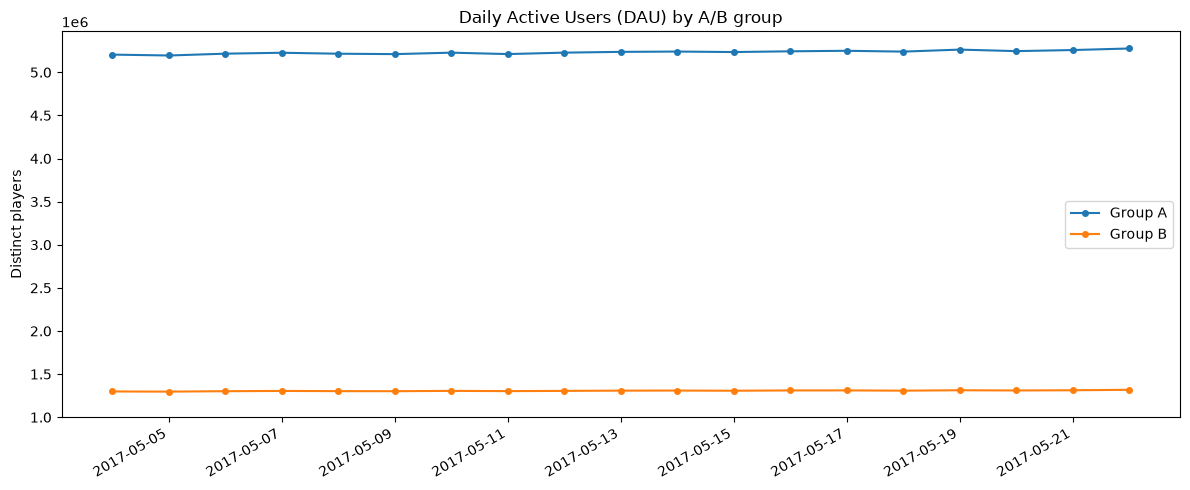

In [15]:
# rerun from the exploration notebook
dau_abtest = """
SELECT
    t.activity_date,
    a.abtest_group,
    count(distinct a.playerid) as dau
FROM `king-ds-recruit-candidate-1114.abtest.assignment` a
LEFT JOIN `king-ds-recruit-candidate-1114.abtest.activity` t
    on a.playerid = t.playerid
WHERE t.activity_date >= "2017-05-04"
GROUP BY all
ORDER BY activity_date
"""
dau_abtest_df = run_query(dau_abtest, save_as=None)

# activity_date is a STRING in BigQuery -> parse to a real date for a time axis
dau_abtest_df["activity_date"] = pd.to_datetime(dau_abtest_df["activity_date"])

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
for group, g in dau_abtest_df.groupby("abtest_group"):
    ax.plot(g["activity_date"], g["dau"], marker="o", markersize=4, label=f"Group {group}")
ax.set_title("Daily Active Users (DAU) by A/B group")
ax.set_ylabel("Distinct players")
ax.set_ylim(bottom=1e6)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## If the bucketing logic is correct? one user - one group, valid dates

In [16]:
groups_per_player = ab_user_level_df.groupby(['playerid'])['abtest_group'].nunique().reset_index()
groups_per_player[groups_per_player['abtest_group'] > 1]


,playerid,abtest_group


- One user only belongs to one group: Valid one
- Data range for ab test is same as stated in the instruction of the assignment (check data quality notebook for this part)

## Randomization balance

CONCLUDE NOTE FROM EXPOLATORY ANALYSIS: 

- Exposure is broad and balanced across all user segments (new vs existing users: non-paying vs spenders). 
- The test targets the general population, in practice dominated by existing non-paying players.

## Sample Ratio Mismatch

Overall share of daily active players by group
  Group A: 80.01%  (99,419,615 active player-days)
  Group B: 19.99%  (24,833,647 active player-days)


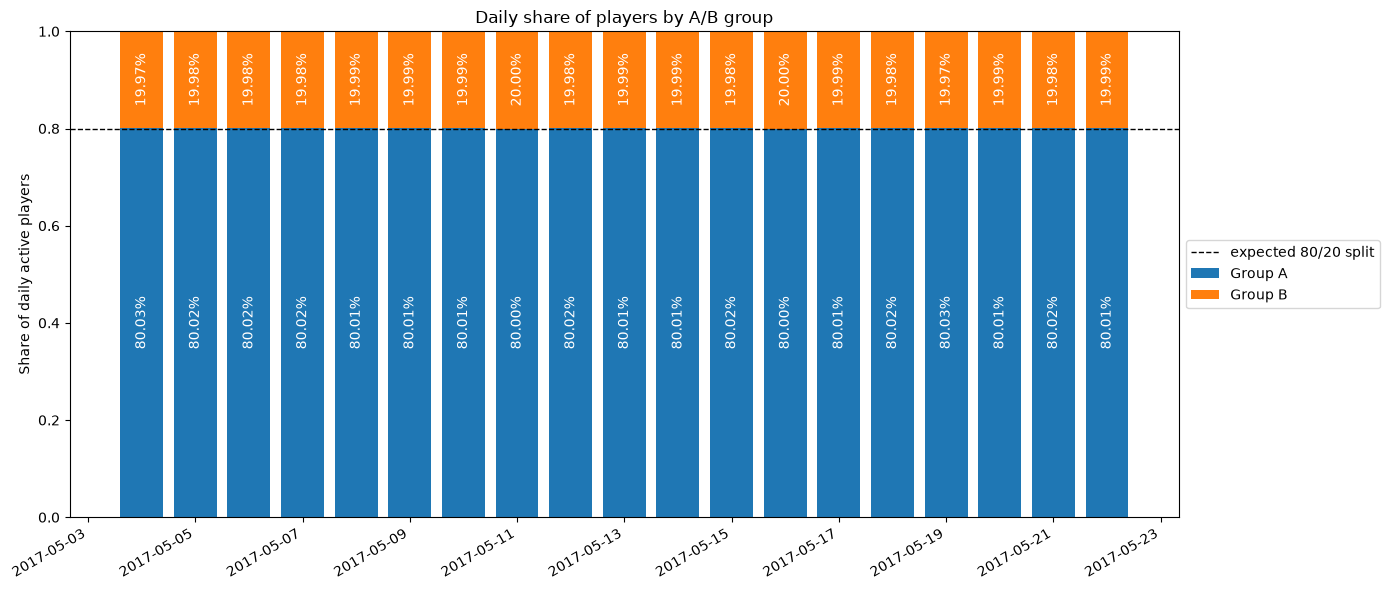

In [17]:
# share of AB users at daily level
# one column per group, then convert each day's counts to shares that sum to 1
pivot = dau_abtest_df.pivot(index="activity_date", columns="abtest_group", values="dau")
share = pivot.div(pivot.sum(axis=1), axis=0)

# overall level: pool every day of the window before taking the share
# (dau summed over days = active player-days, so a player active on 5 days counts 5x)
overall = pivot.sum()
overall_share = overall / overall.sum()
print("Overall share of daily active players by group")
for group, v in overall_share.items():
    print(f"  Group {group}: {v * 100:.2f}%  ({overall[group]:,.0f} active player-days)")

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
bottom = np.zeros(len(share))
for group in share.columns:
    vals = share[group].values
    ax.bar(share.index, vals, bottom=bottom, width=0.8, label=f"Group {group}")
    # label each segment with its share as a 2-decimal percentage
    for x, b, v in zip(share.index, bottom, vals):
        ax.text(x, b + v / 2, f"{v * 100:.2f}%", ha="center", va="center",
                rotation=90, fontsize=10, color="white")
    bottom += vals
ax.axhline(0.8, color="black", linestyle="--", linewidth=1, label="expected 80/20 split")
ax.set_title("Daily share of players by A/B group")
ax.set_ylabel("Share of daily active players")
ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


There is no sign of SRM that the no. users were randomized into the ab test corresponding to the experiment design ratio. But we need to confirm by Chi-square test.

In [18]:
# SRM is a test on the randomisation unit 
EXPECTED_SHARE = {"A": 0.8, "B": 0.2}  # intended design split - flip if it's the other way round

observed = ab_user_level_df.groupby("abtest_group")["playerid"].nunique().sort_index()
expected = pd.Series(EXPECTED_SHARE, dtype=float).reindex(observed.index) * observed.sum()

chi2, p = chisquare(f_obs=observed.values, f_exp=expected.values)

srm = pd.DataFrame({
    "observed": observed,
    "expected": expected.round(0),
    "diff": observed - expected,
    "observed_share": (observed / observed.sum()).round(4),
})
print(srm.to_string())
print(f"\nchi2 = {chi2:,.3f}   df = {len(observed) - 1}   p = {p:.4g}")
print(
    "No SRM: split is consistent with the intended ratio (p >= 0.001)"
    if p >= 0.001
    else "SRM DETECTED (p < 0.001) - fix the assignment before trusting any result"
)


              observed   expected   diff  observed_share
abtest_group                                            
A              8265610  8264845.0  765.2          0.8001
B              2065446  2066211.0 -765.2          0.1999

chi2 = 0.354   df = 1   p = 0.5517
No SRM: split is consistent with the intended ratio (p >= 0.001)


**CONCLUDE**: NO SRM. The split is consistant with the intended ration 80/20. p = 0.5517

## Novelty effect

In [19]:
# Existing-spender ratio per group over the whole period (pre-assignment attribute -> balance check)
engagament_sql = """
with 
  segment as (
SELECT 
  a.playerid, a.activity_date, a.gameends, a.purchases, r.abtest_group,
  DATE(r.conversion_date) as first_purchase_date,
  DATE(r.install_date) as install_date,
  DATE(r.assignment_date) as abtest_random_date,
  a.gameends as number_game_rounds, 
  a.purchases as number_purchases,
  case when r.install_date = r.assignment_date then "new user" else "existing user" end as player_type,
  case 
    when r.conversion_date is null then "non paying player"
    when r.conversion_date < r.assignment_date then "exising spender"
    when r.conversion_date >= r.assignment_date then "new spender"
    else "NA"
  end as spending_type
FROM `king-ds-recruit-candidate-1114.abtest.activity` a
JOIN `king-ds-recruit-candidate-1114.abtest.assignment` r
  on r.playerid = a.playerid
  )

SELECT
  activity_date,
  abtest_group,
  count(distinct playerid) as total_players, --- for the pre-test period, only incl. only the ones in the ab test later
  round(sum(number_game_rounds)/count(distinct playerid),2) as avg_gameround_per_player,
  round(sum(case when number_purchases > 0  then number_game_rounds end)/count(distinct case when number_purchases > 0 then playerid end),2) as avg_gameround_per_paying_player,
  round(sum(case when player_type = "existing user" then number_game_rounds end)/count(distinct case when player_type = "existing user" then playerid end),2) as avg_gameround_per_existing_player,
  round(sum(case when player_type = "new user" then number_game_rounds end)/count(distinct case when player_type = "new user" then playerid end),2) as avg_gameround_per_new_player,
  round(sum(case when spending_type = "non paying player" then number_game_rounds end)/count(distinct case when spending_type = "non paying player" then playerid end),2) as avg_gameround_per_nonpaying_player,
  round(sum(case when spending_type = "exising spender" then number_game_rounds end)/count(distinct case when spending_type = "exising spender" then playerid end),2) as avg_gameround_per_existing_spender,
  round(sum(case when spending_type = "new spender" then number_game_rounds end)/count(distinct case when spending_type = "new spender" then playerid end),2) as avg_gameround_per_new_spender,
  round(100*count(distinct case when number_purchases > 0 then playerid end)/count(distinct playerid),2) as purchase_rate_pct,
  round(sum(number_purchases)/count(distinct playerid),2) as avg_number_purchase_per_player,
  round(sum(case when number_purchases > 0  then number_purchases end)/count(distinct case when number_purchases > 0 then playerid end),2) as avg_purchase_per_paying_player,
  round(sum(case when number_purchases > 0  and player_type = "existing user" then number_purchases end)/count(distinct case when number_purchases > 0  and player_type = "existing user" then playerid end),2) as avg_purchase_per_existing_player_paying,
  round(sum(case when number_purchases > 0  and player_type = "new user" then number_purchases end)/count(distinct case when number_purchases > 0  and player_type = "new user" then playerid end),2) as avg_purchase_per_new_player_paying,
  round(sum(case when spending_type = "exising spender" then number_purchases end)/count(distinct case when spending_type = "exising spender" then playerid end),2) as avg_purchase_per_existing_spender,
  round(sum(case when spending_type = "new spender" then number_purchases end)/count(distinct case when spending_type = "new spender" then playerid end),2) as avg_purchase_per_new_spender,
FROM segment
GROUP BY all
"""
engagament_df = run_query(engagament_sql, save_as=None)

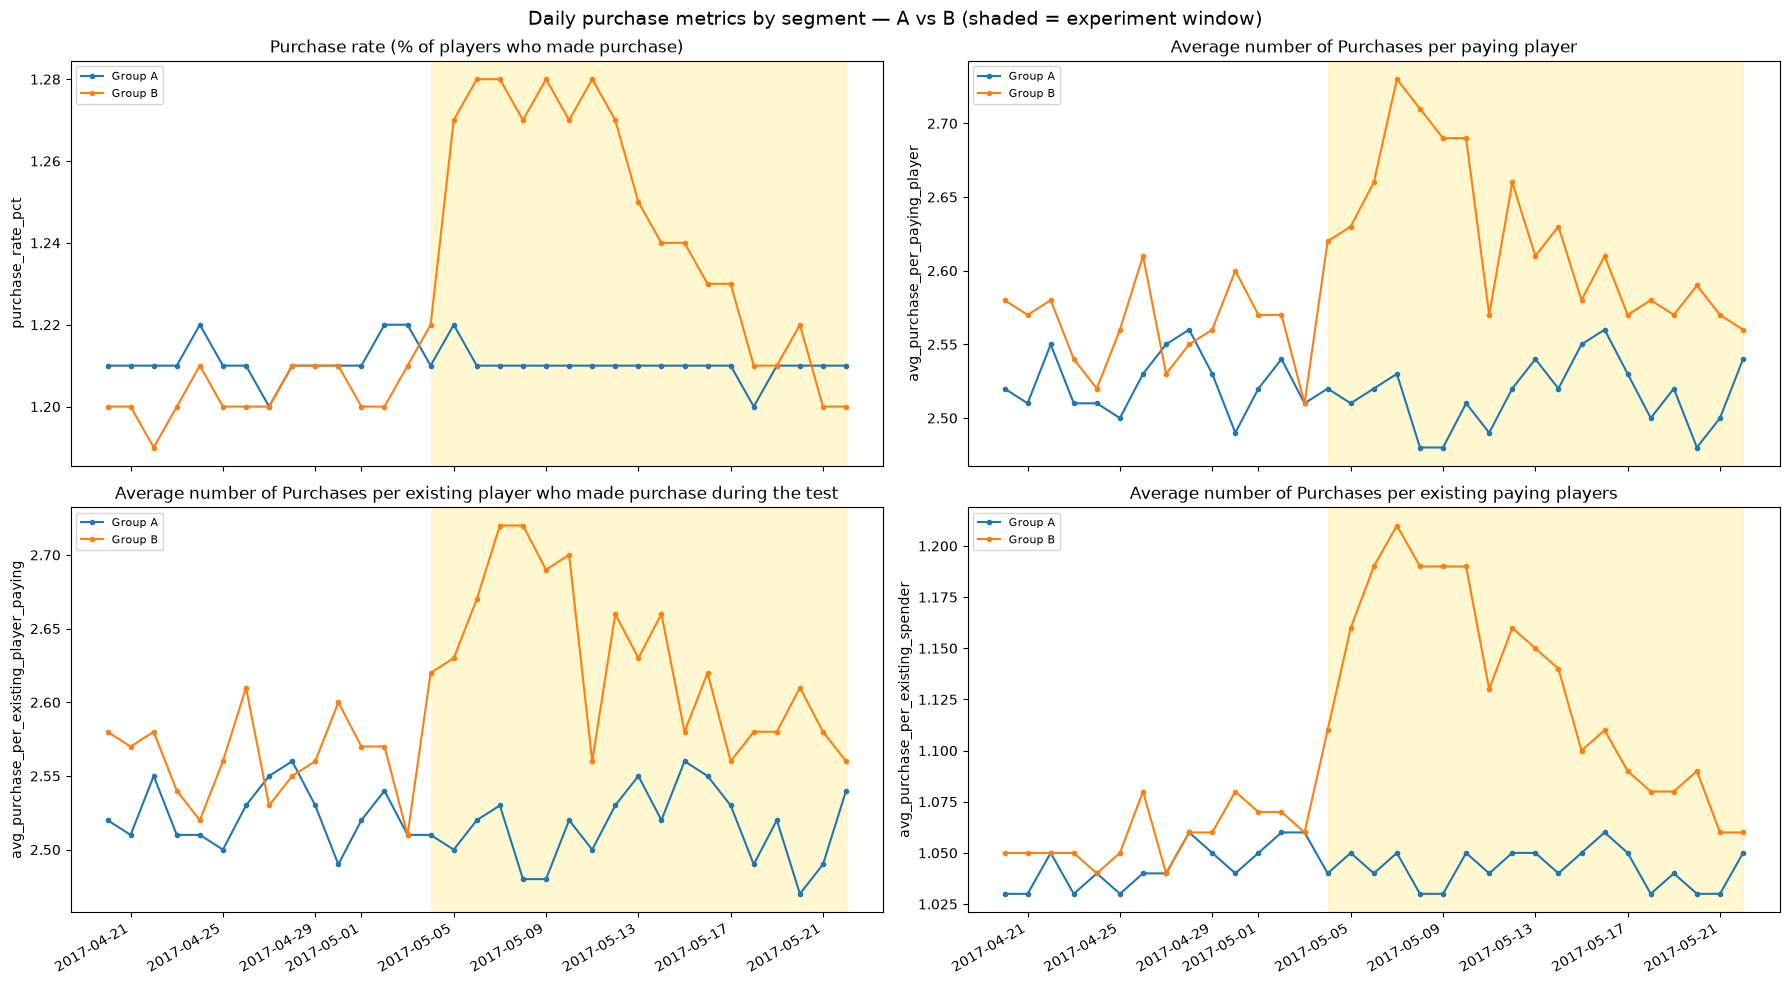

In [20]:
# Purchase metrics, daily trend by segment, A vs B
engagament_df["activity_date"] = pd.to_datetime(engagament_df["activity_date"])
EXP_START, EXP_END = pd.Timestamp("2017-05-04"), pd.Timestamp("2017-05-22")

purchase_metrics = {
    "purchase_rate_pct":                      "Purchase rate (% of players who made purchase)",
    "avg_purchase_per_paying_player":         "Average number of Purchases per paying player",
    "avg_purchase_per_existing_player_paying":"Average number of Purchases per existing player who made purchase during the test",
    "avg_purchase_per_existing_spender":      "Average number of Purchases per existing paying players",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
fig.patch.set_facecolor("white")
axes = axes.ravel()
for ax, (col, title) in zip(axes, purchase_metrics.items()):
    ax.set_facecolor("white")
    for grp in ["A", "B"]:
        d = engagament_df[engagament_df["abtest_group"] == grp].sort_values("activity_date")
        ax.plot(d["activity_date"], d[col], marker="o", markersize=3, label=f"Group {grp}")
    ax.axvspan(EXP_START, EXP_END, color="#FFF3B0", alpha=0.6)
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.legend(fontsize=8)
for ax in axes[len(purchase_metrics):]:
    ax.set_visible(False)

fig.suptitle("Daily purchase metrics by segment — A vs B (shaded = experiment window)", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


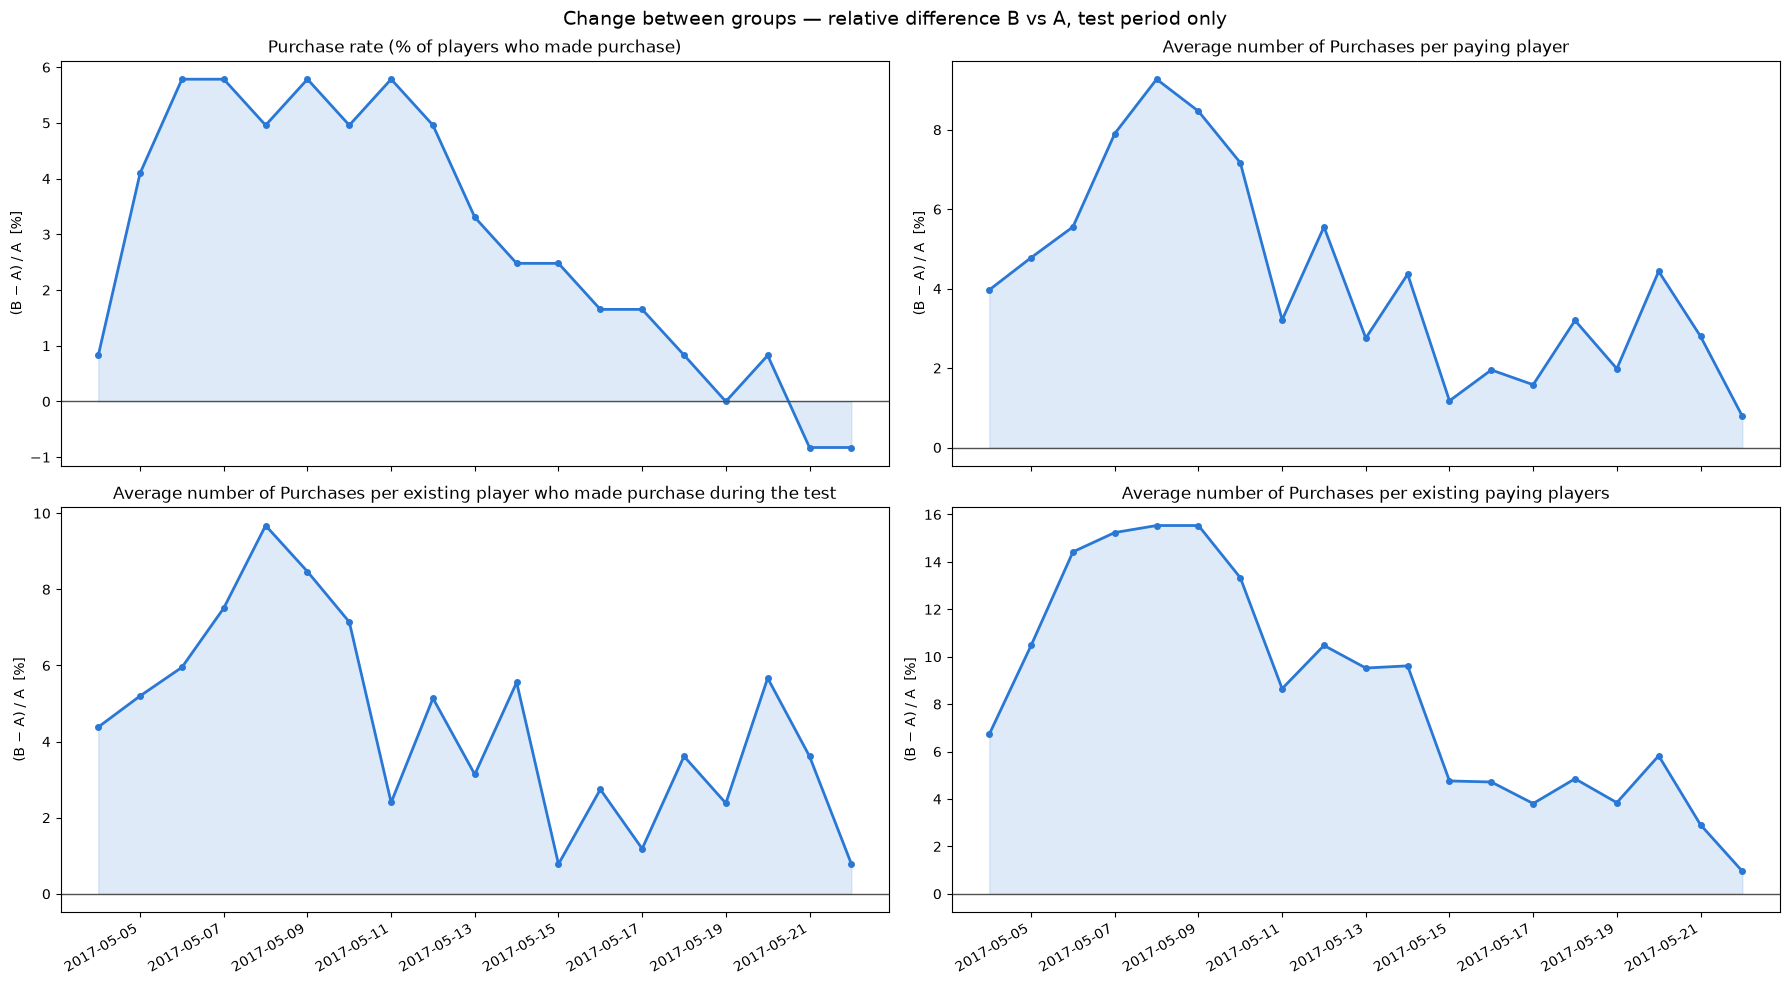

In [21]:
# Change between groups: relative difference (B - A) / A, test period only
# One line per panel makes the *trend of the gap* readable - flat = stable effect, sloping = not settled yet.
wide = engagament_df.pivot(
    index="activity_date", columns="abtest_group", values=list(purchase_metrics)
).sort_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
fig.patch.set_facecolor("white")
axes = axes.ravel()
for ax, (col, title) in zip(axes, purchase_metrics.items()):
    ax.set_facecolor("white")
    rel = (wide[(col, "B")] - wide[(col, "A")]) / wide[(col, "A")] * 100
    rel = rel[(rel.index >= EXP_START) & (rel.index <= EXP_END)]

    ax.fill_between(rel.index, 0, rel.values, color="#2a78d6", alpha=0.15)
    ax.plot(rel.index, rel.values, color="#2a78d6", linewidth=2, marker="o", markersize=4)
    ax.axhline(0, color="#52514e", linewidth=1)

    ax.set_title(title)
    ax.set_ylabel("(B − A) / A  [%]")

fig.suptitle("Change between groups — relative difference B vs A, test period only", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**NOVELTY EFFECT**

All four metrics show the same shape in B while A stays flat: a jump on day 1 (05-04), a peak on 05-08–05-10, then a decay toward A that is **still in progress when the test ends** on 05-22.

| Metric | A (flat) | B peak | Peak lift | B end | End vs A |
|---|---|---|---|---|---|
| Purchase rate (%) | ~1.21 | ~1.28 | **+6%** | ~1.20 | −1% |
| Purchases per paying player | ~2.51 | ~2.73 | **+9%** | ~2.56 | +2% |
| Purchases per existing paying player | ~2.52 | ~2.72 | **+8%** | ~2.56 | +2% |
| Purchases per existing spender | ~1.05 | ~1.21 | **+15%** | ~1.06 | +1% |

- Lift is largest on existing spenders (+15%) and smallest on purchase rate (+6%) → intensified existing buyers rather than recruiting new ones.
- **The "End vs A" column is not a steady state.** None of the four gaps had flattened by 05-22, so these end values are a snapshot of a moving trend, not the converged effect.
- Caveat: in the two "per paying player" panels B already sits above A pre-test — read the change in gap, not the gap.

**The test ran quite short to call.** There is a clear novelty spike, but we cannot distinguish a decay to *zero* from a decay to a *small, stable uplift*, and those imply opposite decisions. A durable +1–2% on purchases per paying player would be worth shipping; zero would not. The decision rule needs a sustained lift, and "sustained" is not yet observable — so this is not grounds to reject B.


**SANITY CHECK CONCLUSION**

- The test runed without any outbreak. 
- The users are randomized into Control and Treatment group according to the design ratio. No SRM here.
- Exposure is broad and balanced across all user segments (new vs existing users: non-paying vs spenders). 
- Novelty effect is observed for the main related purchase metric. But the experiment was ended earlier that the difference in purchase between the two groups were not stabalized yet to observe a stable effect here.

# AB Test Performance Metrics

## Primary (success) metric

**Capped average number of purchase per player**

t-test with unequal variance
p-value (0.05)
CI 95%

Segment the metric by spender group, by new vs existing user groups to check Simpson paradox

-- Data limitation: no platform, no market

In [22]:
ab_user_level_df['capped_number_purchase'] = ab_user_level_df['number_purchases'].clip(upper=111)

**Statistical Test**

In [ ]:
# Welch's t-test (unequal variance)
def welch_report(a, b, label, relative=True, alternative="greater"):
    """Welch's t-test (unequal variance),
    alternative: "greater" -> H1: B > A (default); "less" -> H1: B < A; "two-sided" -> H1: B != A.
    Drives which p-value the verdict line reads."""
    a = pd.Series(a).dropna().to_numpy(dtype=float)
    b = pd.Series(b).dropna().to_numpy(dtype=float)
    n_a, n_b = a.size, b.size
    m_a, m_b = a.mean(), b.mean()
    v_a, v_b = a.var(ddof=1), b.var(ddof=1)

    diff = m_b - m_a
    se = np.sqrt(v_a / n_a + v_b / n_b)
    dof = se**4 / ((v_a / n_a) ** 2 / (n_a - 1) + (v_b / n_b) ** 2 / (n_b - 1))
    ci_lo, ci_hi = diff - stats.t.ppf(0.975, dof) * se, diff + stats.t.ppf(0.975, dof) * se
    t_stat, p_two = stats.ttest_ind(b, a, equal_var=False)
    _, p_alt = stats.ttest_ind(b, a, equal_var=False, alternative=alternative)

    tag = {"greater": "B>A", "less": "B<A", "two-sided": "B!=A"}[alternative]
    rel = f"   ({diff / m_a * 100:+.2f}% relative)" if relative and m_a > 0 else ""
    print(f"=== {label} ===")
    print(f"  A: n={n_a:>10,}   mean={m_a:.5f}")
    print(f"  B: n={n_b:>10,}   mean={m_b:.5f}")
    print(f"  B - A                = {diff:+.5f}{rel}")
    print(f"  95% CI               = [{ci_lo:+.5f}, {ci_hi:+.5f}]")
    print(f"  Welch t = {t_stat:.3f}   df = {dof:,.0f}   p (two-sided) = {p_two:.4g}   p ({alternative}, {tag}) = {p_alt:.4g}")
    print(f"  REJECT H0 at 0.05 ({tag})\n" if p_alt < 0.05 else f"  FAIL TO REJECT H0 at 0.05 ({tag})\n")

In [36]:
# Two-proportion z-test - for binary (0/1 or bool) metrics.
def proportion_z_test(a, b, label, alternative="greater"):
    """Two-proportion z-test, B vs A. Pooled variance for the test (H0: p_A = p_B), unpooled for the CI.
    alternative: "greater" -> H1: B > A (default); "less" -> H1: B < A; "two-sided" -> H1: B != A."""
    a = pd.Series(a).dropna().astype(float).to_numpy()
    b = pd.Series(b).dropna().astype(float).to_numpy()
    n_a, n_b = a.size, b.size
    x_a, x_b = a.sum(), b.sum()
    p_a, p_b = x_a / n_a, x_b / n_b

    diff = p_b - p_a
    se_ci = np.sqrt(p_a * (1 - p_a) / n_a + p_b * (1 - p_b) / n_b)   # unpooled -> CI
    ci_lo, ci_hi = diff - 1.96 * se_ci, diff + 1.96 * se_ci
    pp = (x_a + x_b) / (n_a + n_b)                                    # pooled -> test
    z = diff / np.sqrt(pp * (1 - pp) * (1 / n_a + 1 / n_b))

    p_two = 2 * (1 - stats.norm.cdf(abs(z)))
    p_alt = {"greater": 1 - stats.norm.cdf(z),
             "less": stats.norm.cdf(z),
             "two-sided": p_two}[alternative]
    tag = {"greater": "B>A", "less": "B<A", "two-sided": "B!=A"}[alternative]

    print(f"=== {label} ===")
    print(f"  A: n={n_a:>10,}   rate = {p_a * 100:.3f}%")
    print(f"  B: n={n_b:>10,}   rate = {p_b * 100:.3f}%")
    print(f"  B - A = {diff * 100:+.3f} pp   95% CI [{ci_lo * 100:+.3f}, {ci_hi * 100:+.3f}]")
    print(f"  z = {z:.3f}   p (two-sided) = {p_two:.4g}   p ({alternative}, {tag}) = {p_alt:.4g}")
    print(f"  REJECT H0 at 0.05 ({tag})\n" if p_alt < 0.05 else f"  FAIL TO REJECT H0 at 0.05 ({tag})\n")


In [24]:
# Welch's t-test (unequal variance) on the capped primary metric
a = ab_user_level_df.loc[ab_user_level_df["abtest_group"] == "A", "capped_number_purchase"].dropna().astype(float).to_numpy()
b = ab_user_level_df.loc[ab_user_level_df["abtest_group"] == "B", "capped_number_purchase"].dropna().astype(float).to_numpy()

welch_report(a, b, "Capped purchases per player (cap = 111 = pre-test p99))")


=== Capped purchases per player (cap = 111 = pre-test p99)) ===
  A: n= 8,265,610   mean=0.29788
  B: n= 2,065,446   mean=0.31206
  B - A                = +0.01417   (+4.76% relative)
  95% CI               = [+0.00883, +0.01952]
  Welch t = 5.198   df = 3,092,323   p (two-sided) = 2.011e-07   p (greater, B>A) = 1.006e-07
  REJECT H0 at 0.05 (B>A)



**Purchase metric at # segments**

Simpson Paradox checking

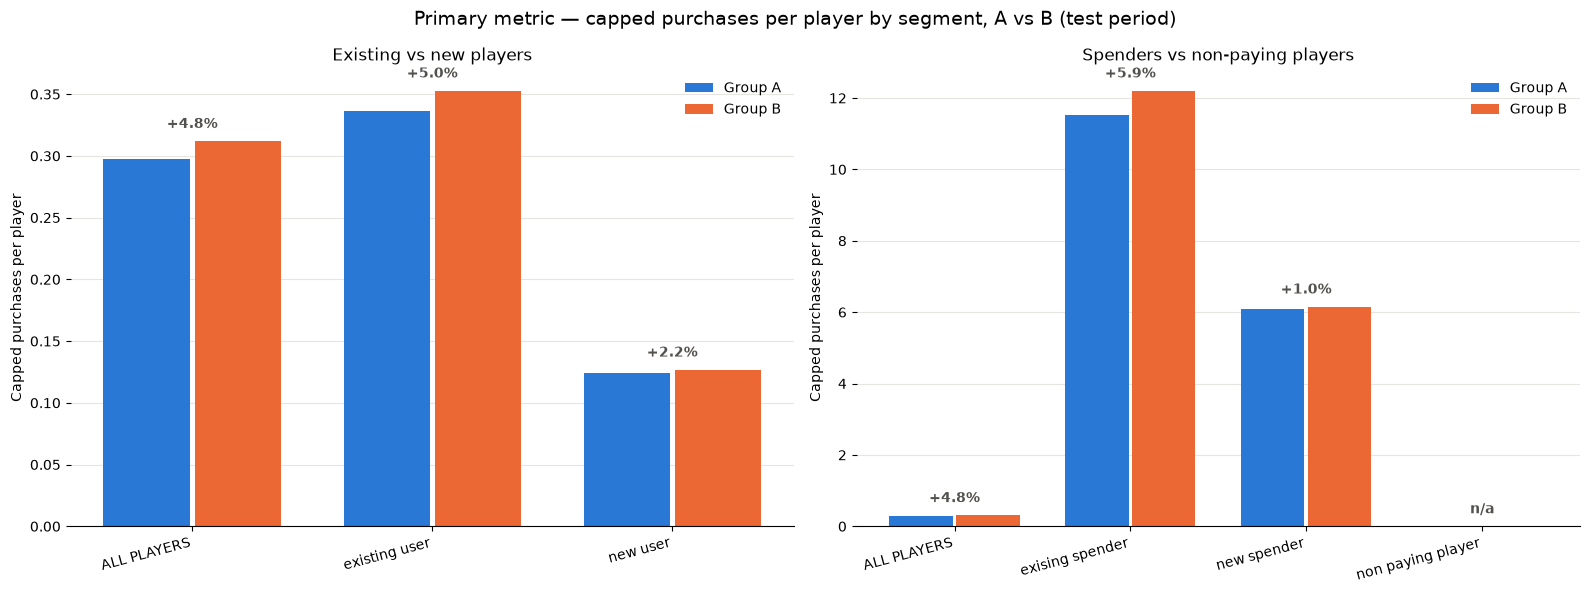

In [25]:
# Primary metric by segment, A vs B - Simpson's paradox check
# ab_user_level_df is already restricted to activity_date >= assignment_date, i.e. the test period.
SEGMENTS = {
    "player_type":   "Existing vs new players",
    "spending_type": "Spenders vs non-paying players",
}
COLORS = {"A": "#2a78d6", "B": "#eb6834"}
METRIC = "capped_number_purchase"

overall = ab_user_level_df.groupby("abtest_group")[METRIC].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("white")
for ax, (col, title) in zip(axes, SEGMENTS.items()):
    ax.set_facecolor("white")
    means = ab_user_level_df.groupby([col, "abtest_group"])[METRIC].mean().unstack("abtest_group")
    means.loc["ALL PLAYERS"] = overall                     # reference row for the Simpson check
    means = means.loc[["ALL PLAYERS"] + [i for i in means.index if i != "ALL PLAYERS"]]

    x = np.arange(len(means))
    w = 0.38
    for i, grp in enumerate(["A", "B"]):
        ax.bar(x + (i - 0.5) * w, means[grp], width=w - 0.02, color=COLORS[grp], label=f"Group {grp}")

    # relative lift above each pair - this is what a Simpson reversal would show up in
    for xi, (_, row) in enumerate(means.iterrows()):
        lift = (row["B"] - row["A"]) / row["A"] * 100 if row["A"] > 0 else np.nan
        label = f"{lift:+.1f}%" if np.isfinite(lift) else "n/a"
        ax.text(xi, max(row["A"], row["B"]) + means.max().max() * 0.03, label,
                ha="center", fontsize=10, fontweight="bold", color="#52514e")

    ax.set_xticks(x)
    ax.set_xticklabels(means.index, rotation=15, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Capped purchases per player")
    ax.grid(axis="y", color="#e6e5e1", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.legend(frameon=False)

fig.suptitle("Primary metric — capped purchases per player by segment, A vs B (test period)", fontsize=14)
plt.tight_layout()
plt.show()


On the statistics alone, there is evidence to reject the null hypothesis in favour of the alternative one. Capped purchases per player is +0.014 (+4.8%) in B, 95% CI [+0.009, +0.020], one-sided p ≈ 1e-7 (<< 0.05). The direction is consistent across every segment, so it is not driven by one subgroup.

However, this +4.8% is the average across the whole test window, and the daily B−A gap was still shrinking at the end (22/05):it had not stablaized yet. So this number reflects the early novelty spike, not a stable long-term effect. So the result is not trustworhty and so not enough to decide on shipping. The experiment should run longer, until the daily B−A gap stays flat.

## Guardrail metrics

- (uncaped) purchase per player
- game rounds per player: not meaningfully lower in B (a small drop is acceptable; a large one is not).
- 7-day retention: not lower in B (protects long-term player base against frustration/churn).

Segment the metric by spender group, by new vs existing user groups to check Simpson paradox

In [27]:
# Guardrail 1 - uncapped purchases per player (does the raw metric agree with the capped primary?)
welch_report(
    ab_user_level_df.loc[ab_user_level_df["abtest_group"] == "A", "number_purchases"],
    ab_user_level_df.loc[ab_user_level_df["abtest_group"] == "B", "number_purchases"],
    "Number of purchases per player",
)

# Guardrail 2 - game rounds per player (engagement cost). We expect a drop, so test H1: B < A.
a = ab_user_level_df.loc[ab_user_level_df["abtest_group"] == "A", "number_game_rounds"].dropna().to_numpy(dtype=float)
b = ab_user_level_df.loc[ab_user_level_df["abtest_group"] == "B", "number_game_rounds"].dropna().to_numpy(dtype=float)
welch_report(a, b, label, relative=True, alternative="less")

=== Number of purchases per player ===
  A: n= 8,265,610   mean=0.36621
  B: n= 2,065,446   mean=0.39257
  B - A                = +0.02636   (+7.20% relative)
  95% CI               = [+0.01162, +0.04110]
  Welch t = 3.504   df = 3,116,034   p (two-sided) = 0.0004576   p (greater, B>A) = 0.0002288
  REJECT H0 at 0.05 (B>A)

=== n/a ===
  A: n= 8,265,610   mean=158.56344
  B: n= 2,065,446   mean=155.49050
  B - A                = -3.07294   (-1.94% relative)
  95% CI               = [-3.28254, -2.86334]
  Welch t = -28.735   df = 3,226,624   p (two-sided) = 1.476e-181   p (less, B<A) = 7.378e-182
  REJECT H0 at 0.05 (B<A)



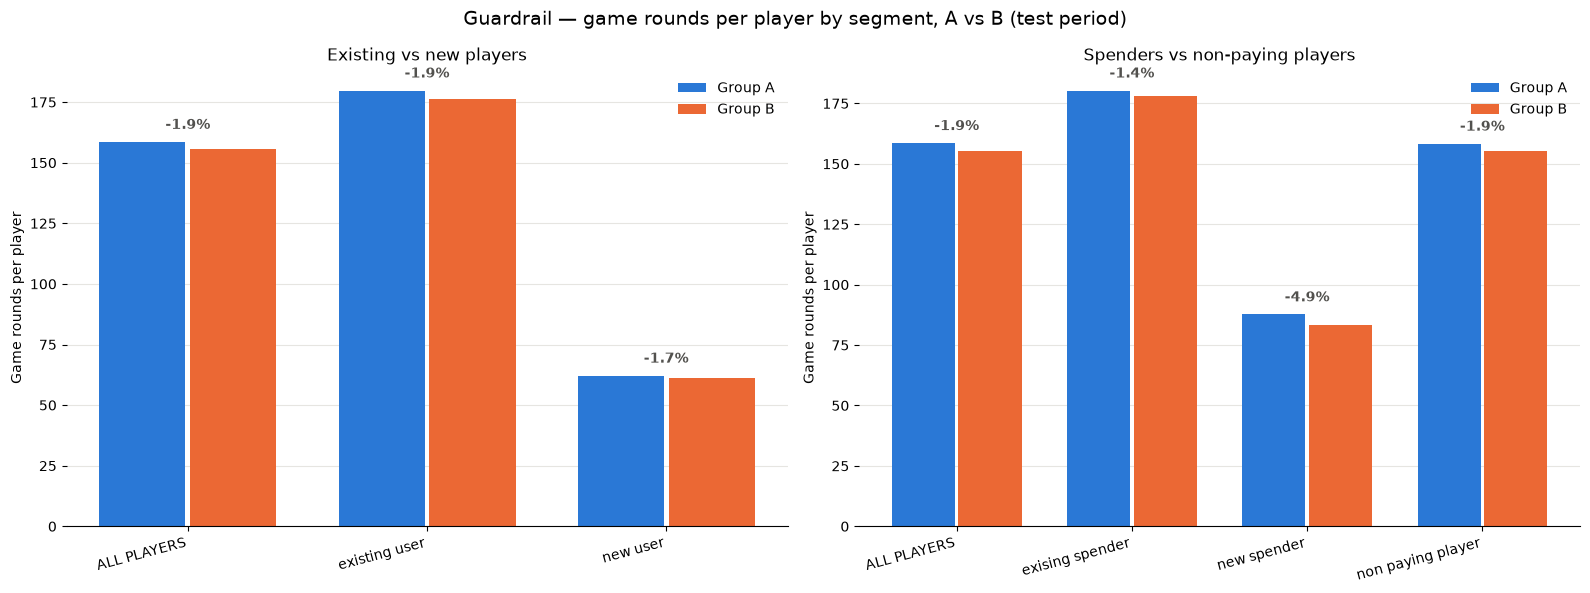

In [28]:
# Game rounds per player by segment, A vs B - same layout as the primary-metric segment chart
SEGMENTS = {
    "player_type":   "Existing vs new players",
    "spending_type": "Spenders vs non-paying players",
}
COLORS = {"A": "#2a78d6", "B": "#eb6834"}
METRIC = "number_game_rounds"

overall = ab_user_level_df.groupby("abtest_group")[METRIC].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("white")
for ax, (col, title) in zip(axes, SEGMENTS.items()):
    ax.set_facecolor("white")
    means = ab_user_level_df.groupby([col, "abtest_group"])[METRIC].mean().unstack("abtest_group")
    means.loc["ALL PLAYERS"] = overall                     # reference row
    means = means.loc[["ALL PLAYERS"] + [i for i in means.index if i != "ALL PLAYERS"]]

    x = np.arange(len(means))
    w = 0.38
    for i, grp in enumerate(["A", "B"]):
        ax.bar(x + (i - 0.5) * w, means[grp], width=w - 0.02, color=COLORS[grp], label=f"Group {grp}")

    # relative change B vs A above each pair (negative = B plays fewer rounds)
    for xi, (_, row) in enumerate(means.iterrows()):
        chg = (row["B"] - row["A"]) / row["A"] * 100 if row["A"] > 0 else np.nan
        label = f"{chg:+.1f}%" if np.isfinite(chg) else "n/a"
        ax.text(xi, max(row["A"], row["B"]) + means.max().max() * 0.03, label,
                ha="center", fontsize=10, fontweight="bold", color="#52514e")

    ax.set_xticks(x)
    ax.set_xticklabels(means.index, rotation=15, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Game rounds per player")
    ax.grid(axis="y", color="#e6e5e1", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.legend(frameon=False)

fig.suptitle("Guardrail — game rounds per player by segment, A vs B (test period)", fontsize=14)
plt.tight_layout()
plt.show()


The two guardrails move in opposite directions:

- **Number of purchases per player (uncapped) — up, agrees with the primary.** A = 0.366, B = 0.393, diff +0.026 (+7.2%), 95% CI [+0.012, +0.041], p ≈ 0.0002288. Reject H₀. 
- **Game rounds per player — down, significant.** A = 158.6, B = 155.5, diff −3.07 rounds (−1.94%), 95% CI [−3.28, −2.86]. Tested one-sided for a drop (H₁: B < A), p ≈ 7e-182 → reject H₀: B plays significantly fewer rounds.

So B buys more but plays less, consistent with the treatment mechanic (harder levels → fewer completed rounds).

**By segment** (chart above), the round drop is broad-based, not concentrated:

| Segment | A | B | change |
|---|---|---|---|
| Existing players | 179.8 | 176.3 | −1.9% |
| New players | 62.1 | 61.1 | −1.7% |
| Existing spenders | 180.3 | 177.9 | −1.4% |
| Non-paying players | 158.3 | 155.3 | −1.9% |
| New spenders | 87.7 | 83.4 | −4.9% |

Every segment falls ~1.4–1.9%, so the engagement cost is spread across the whole base rather than sitting in one group. It is a real, uniform cost, not noise.


**Retention metric**

In [37]:
# 7-day retention guardrail - two-proportion z-test, harm direction B < A
proportion_z_test(
    retention_assignment_date_df.loc[retention_assignment_date_df["abtest_group"] == "A", "retention_7days"],
    retention_assignment_date_df.loc[retention_assignment_date_df["abtest_group"] == "B", "retention_7days"],
    "7-day retention (active again within 7 days of assignment)",
    alternative="less",
)


=== 7-day retention (active again within 7 days of assignment) ===
  A: n= 8,265,610   rate = 92.345%
  B: n= 2,065,446   rate = 92.320%
  B - A = -0.025 pp   95% CI [-0.066, +0.015]
  z = -1.229   p (two-sided) = 0.219   p (less, B<A) = 0.1095
  FAIL TO REJECT H0 at 0.05 (B<A)



No evidence to conclude that the new experience reduces the retention rate. However, the frustuation built up due to the "incomfort" difficulty to pass a level is a accumulated function over time (several weeks or months) so the question if the retention metric is good enough to measure it is a question mark.

## Secondary metrics

- purchase rate (% buying) 
- average number of purchases per spender: higher in B, confirming the hint-buying mechanism.

In [38]:
# Secondary metric 1 - purchase rate: share of players with >=1 purchase during the test (binary -> two-proportion z).
is_buyer = ab_user_level_df["number_purchases"] > 0
proportion_z_test(
    is_buyer[ab_user_level_df["abtest_group"] == "A"],
    is_buyer[ab_user_level_df["abtest_group"] == "B"],
    "Purchase rate (share of players who purchased during the test)",
    alternative="greater",
)

# Secondary metric 2 - avg purchases per spender. Mean/count, not a proportion -> Welch t.
spenders = ab_user_level_df[ab_user_level_df["number_purchases"] > 0]
welch_report(
    spenders.loc[spenders["abtest_group"] == "A", "number_purchases"],
    spenders.loc[spenders["abtest_group"] == "B", "number_purchases"],
    "Avg purchases per spender",
)


=== Purchase rate (share of players who purchased during the test) ===
  A: n= 8,265,610   rate = 2.690%
  B: n= 2,065,446   rate = 2.689%
  B - A = -0.001 pp   95% CI [-0.026, +0.024]
  z = -0.074   p (two-sided) = 0.9409   p (greater, B>A) = 0.5295
  FAIL TO REJECT H0 at 0.05 (B>A)

=== Avg purchases per spender ===
  A: n=   222,348   mean=13.61360
  B: n=    55,542   mean=14.59856
  B - A                = +0.98495   (+7.24% relative)
  95% CI               = [+0.45291, +1.51700]
  Welch t = 3.628   df = 83,925   p (two-sided) = 0.0002853   p (greater, B>A) = 0.0001426
  REJECT H0 at 0.05 (B>A)



The two secondary metrics split cleanly, and together they explain where the primary lift comes from:

- **Purchase rate - no effect.** A = 2.690%, B = 2.689%, diff −0.03%, 95% CI [−0.026%, +0.024%], p ≈ 0.94. Fail to reject H₀. The treatment did **not** get more players to buy. The size of the buyer base is unchanged.
- **Avg purchases per spender — significant lift.** A = 13.61, B = 14.60, diff +0.99 (+7.24%), 95% CI [+0.45, +1.52], one-sided p ≈ 0.0001426. Reject H₀ in favour of H₁: existing buyers bought more.

Put together: the +4.8% primary lift is intensity, not breadth mainly from the paying players spending more. This matches the novelty finding, where the daily lift was largest on existing spenders while purchase rate barely moved.

Notes: 
1. These were during the test, so they average the early novelty spike with the decay instead of a stable long-term effect. 
2. "Spender" is defined by purchasing during the test.


# Other deep dive topics

### Retention

In [8]:
retention_sql = """
with
  base as (
SELECT
  a.playerid,
  DATE(a.activity_date) as activity_date,
  r.abtest_group,
  a.purchases,
  case when r.install_date = r.assignment_date then "new user" else "existing user" end as player_type
FROM `king-ds-recruit-candidate-1114.abtest.activity` a
JOIN `king-ds-recruit-candidate-1114.abtest.assignment` r
  on r.playerid = a.playerid
WHERE DATE(a.activity_date) >= DATE(r.assignment_date)
  ),

  flagged as (
SELECT
  s.playerid,
  s.activity_date,
  s.abtest_group,
  s.player_type,
  s.purchases,
  -- did this player come back on another day within the next 7 days?
  logical_or(f.playerid is not null) as returned_within_7
FROM base s
LEFT JOIN base f
  on f.playerid = s.playerid
  and f.activity_date > s.activity_date
  and f.activity_date <= DATE_ADD(s.activity_date, INTERVAL 7 DAY)
GROUP BY s.playerid, s.activity_date, s.abtest_group, s.player_type, s.purchases
  )

SELECT
  activity_date,
  abtest_group,
  count(distinct playerid) as total_players,
  count(distinct if(player_type = "new user", playerid, null)) as number_new_players,
  count(distinct if(player_type = "existing user", playerid, null)) as number_existing_players,
  count(distinct if(purchases > 0, playerid, null)) as number_spenders,
  count(distinct if(returned_within_7, playerid, null)) as number_users_return_to_play_within_7_days,
  count(distinct if(returned_within_7 and player_type = "new user", playerid, null)) as number_new_users_return_to_play_within_7_days,
  count(distinct if(returned_within_7 and purchases > 0, playerid, null)) as number_spenders_return_to_play_within_7_days
FROM flagged
GROUP BY activity_date, abtest_group
ORDER BY activity_date, abtest_group
"""
retention_df = run_query(retention_sql, save_as="retention")

print(retention_df.head(5))


  activity_date abtest_group  total_players  number_new_players  \
0    2017-05-04            A        5204864               76809   
1    2017-05-04            B        1298934               19114   
2    2017-05-05            A        5194697              103473   
3    2017-05-05            B        1297264               25789   
4    2017-05-06            A        5215813              159737   

   number_existing_players  number_spenders  \
0                  5128055            63132   
1                  1279820            15809   
2                  5091224            63162   
3                  1271475            16484   
4                  5056076            62937   

   number_users_return_to_play_within_7_days  \
0                                    5130703   
1                                    1280219   
2                                    5125007   
3                                    1279785   
4                                    5137553   

   number_new_users_retur

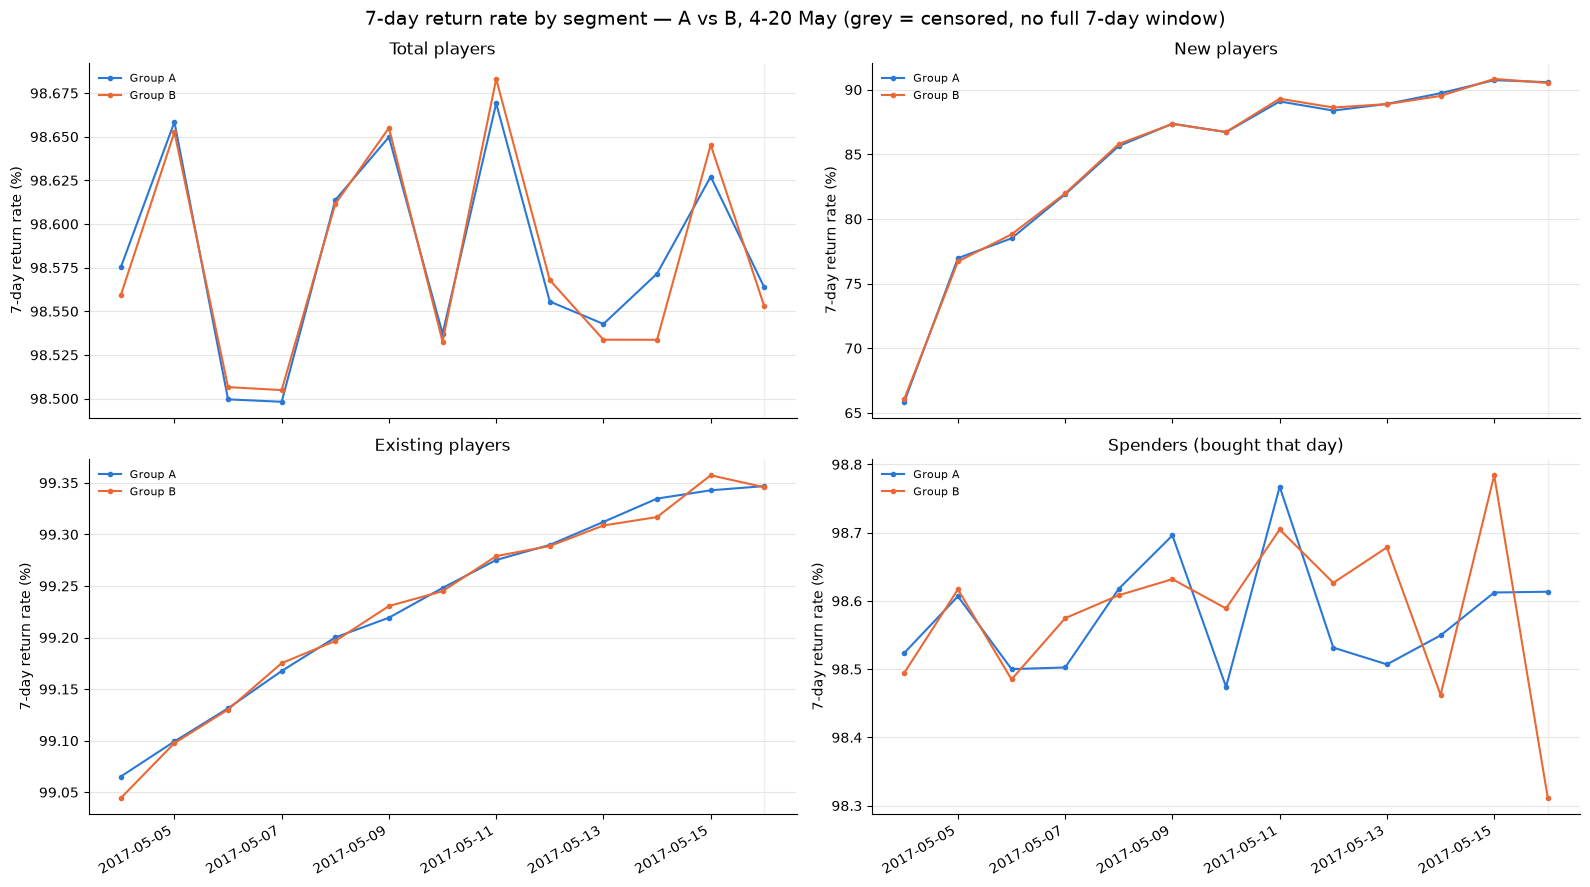

In [5]:
# 7-day return rate = share of a day's active users who play again within the next 7 days, A vs B
ret = retention_df.copy()
ret["activity_date"] = pd.to_datetime(ret["activity_date"])
# existing-player returns aren't a column: player_type is binary, so existing = total - new
ret["existing_return"] = (
    ret["number_users_return_to_play_within_7_days"] - ret["number_new_users_return_to_play_within_7_days"]
)

# restrict to 4th - 20th May
PLOT_START, PLOT_END = pd.Timestamp("2017-05-04"), pd.Timestamp("2017-05-16")
ret = ret[(ret["activity_date"] >= PLOT_START) & (ret["activity_date"] <= PLOT_END)]

COLORS = {"A": "#2a78d6", "B": "#eb6834"}
panels = {
    "Total players":               ("number_users_return_to_play_within_7_days",     "total_players"),
    "New players":                 ("number_new_users_return_to_play_within_7_days", "number_new_players"),
    "Existing players":            ("existing_return",                               "number_existing_players"),
    "Spenders (bought that day)":  ("number_spenders_return_to_play_within_7_days",  "number_spenders"),
}

# dates after this have no full 7-day look-ahead (window runs past 2017-05-22) -> censored
censor_start = pd.Timestamp("2017-05-22") - pd.Timedelta(days=6)

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
fig.patch.set_facecolor("white")
axes = axes.ravel()
for ax, (title, (num, den)) in zip(axes, panels.items()):
    ax.set_facecolor("white")
    for grp in ["A", "B"]:
        d = ret[ret["abtest_group"] == grp].sort_values("activity_date")
        rate = d[num] / d[den] * 100
        ax.plot(d["activity_date"], rate, marker="o", markersize=3, color=COLORS[grp], label=f"Group {grp}")
    ax.axvspan(censor_start, PLOT_END, color="#e6e5e1", alpha=0.6)  # censored tail
    ax.set_title(title)
    ax.set_ylabel("7-day return rate (%)")
    ax.grid(axis="y", color="#e6e5e1", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("7-day return rate by segment — A vs B, 4-20 May (grey = censored, no full 7-day window)", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


- Overall, the retention rate is very high at all # segments and for both groups, ~ 98%. It means that all most all players returned to play within 7 days.
- There is no clear difference in retention between Control and Treatment groups. It follows quite same pattern, swinging around 98.5% at the overall level for both Group A and B while increaseing from over 99% (4 May) to 99.4% (15 May) in both groups.

So currently there was no sign of the new experience would harm the retention of players. However, the data was only one week while the frustuation built up due to the "incomfort" difficulty to pass a level is a accumulated function over time (several weeks or months).

### Repeat purchase. Did first-week buyers buy again?

Cohort: players who made a purchase in week 1 (05-04 → 05-10).
- Outcome: did the same player buy again in 05-11 → 05-22 (return-to-buy).

In [6]:
repeat_buy_sql = """
with
  base as (
SELECT
  a.playerid,
  DATE(a.activity_date) as ad,
  a.purchases,
  r.abtest_group
FROM `king-ds-recruit-candidate-1114.abtest.activity` a
JOIN `king-ds-recruit-candidate-1114.abtest.assignment` r
  on r.playerid = a.playerid
WHERE DATE(a.activity_date) >= DATE(r.assignment_date)
  ),

  week1_buyers as (
SELECT distinct playerid, abtest_group
FROM base
WHERE purchases > 0 AND ad BETWEEN "2017-05-04" AND "2017-05-10"
  )

SELECT
  w.playerid,
  w.abtest_group,
  -- did this week-1 buyer purchase again in week 2+ (05-11 .. 05-22)?
  coalesce(logical_or(b.purchases > 0 AND b.ad BETWEEN "2017-05-11" AND "2017-05-22"), false) as bought_again
FROM week1_buyers w
LEFT JOIN base b
  on b.playerid = w.playerid
GROUP BY w.playerid, w.abtest_group
"""
repeat_buy_df = run_query(repeat_buy_sql, save_as="repeat_buy")

print(repeat_buy_df.groupby("abtest_group")["bought_again"].agg(["size", "mean"]))


                size      mean
abtest_group                  
A             176337  0.891146
B              44556  0.894268


=== Repeat-purchase rate among week-1 buyers (bought again in 05-11..05-22) ===
  A: n=   176,337   rate = 89.115%
  B: n=    44,556   rate = 89.427%
  B - A = +0.312 pp   95% CI [-0.008, +0.633]
  z = 1.895   p (two-sided) = 0.05806   p (two-sided, B!=A) = 0.05806
  FAIL TO REJECT H0 at 0.05 (B!=A)

  => B repeats MORE -> looks incremental


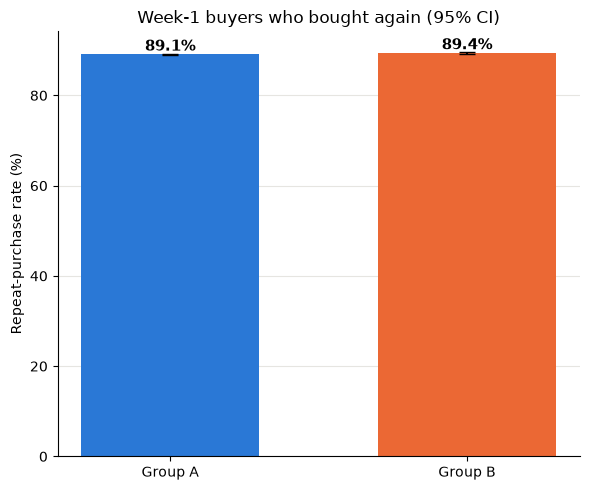

In [39]:
# Repeat-buy rate B vs A among week-1 buyers - two-proportion z-test + chart
proportion_z_test(
    repeat_buy_df.loc[repeat_buy_df["abtest_group"] == "A", "bought_again"],
    repeat_buy_df.loc[repeat_buy_df["abtest_group"] == "B", "bought_again"],
    "Repeat-purchase rate among week-1 buyers (bought again in 05-11..05-22)",
    alternative="two-sided",
)

# per-group rate + n for the chart (and a directional read for incremental vs pull-forward)
g = repeat_buy_df.groupby("abtest_group")["bought_again"]
n = g.size()
p = g.mean()
print("  => " + ("B repeats MORE -> looks incremental" if p["B"] > p["A"] else "B repeats LESS/EQUAL -> pull-forward signature"))

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
COLORS = {"A": "#2a78d6", "B": "#eb6834"}
for i, grp in enumerate(["A", "B"]):
    err = 1.96 * np.sqrt(p[grp] * (1 - p[grp]) / n[grp]) * 100
    ax.bar(i, p[grp] * 100, width=0.6, color=COLORS[grp], yerr=err, capsize=6)
    ax.text(i, p[grp] * 100, f"{p[grp] * 100:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Group A", "Group B"])
ax.set_ylabel("Repeat-purchase rate (%)")
ax.set_title("Week-1 buyers who bought again (95% CI)")
ax.grid(axis="y", color="#e6e5e1", linewidth=0.8)
ax.set_axisbelow(True)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
plt.tight_layout()
plt.show()


- The return-to-purchase rate for the purchase cohort of the experiment is little higher in Treatment (89.4%) than in the Control group (89.1%). This is not statistical significant difference. 
- So it seems that there is not a sign of "forward purchase" cannibalization yet. 

Now, we will take a look of new spender group below to see if the treatment converts any existing non-paying players to spenders during the test.

### New spenders

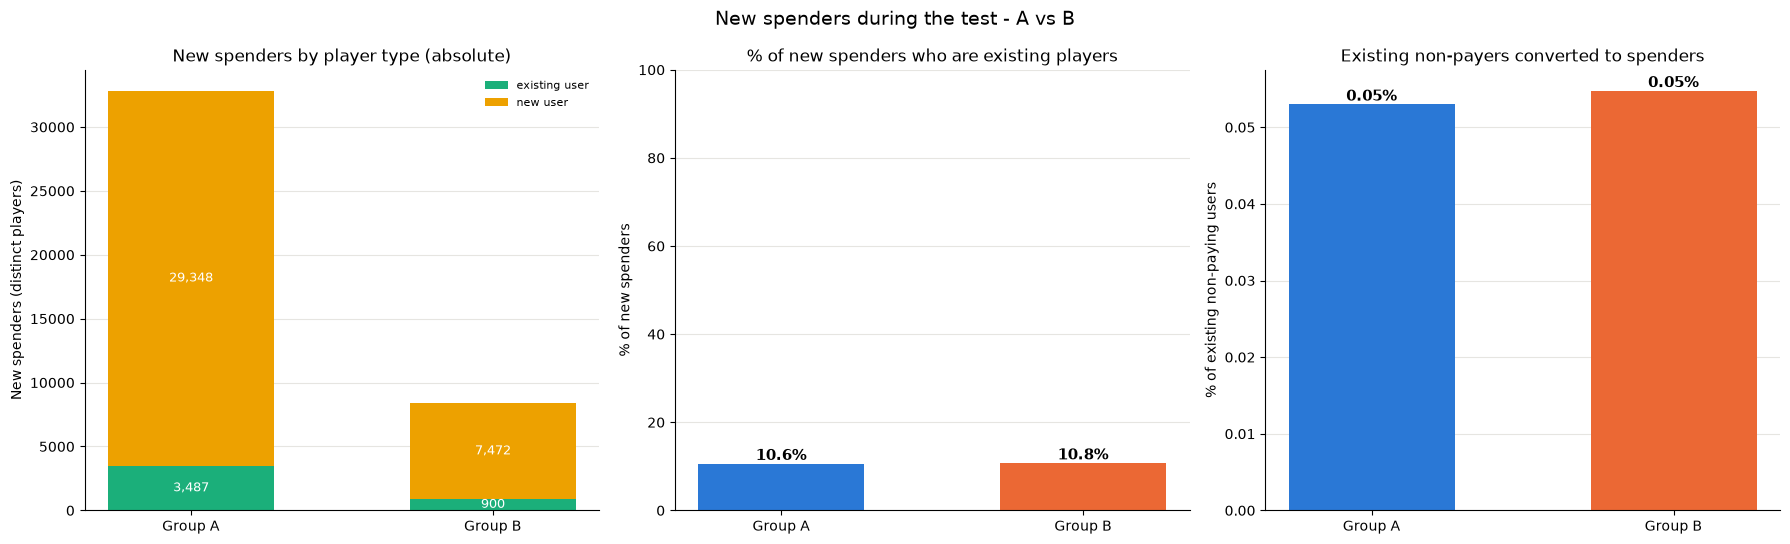

In [33]:
# New spenders (converted during the test) - how many are existing players, and the conversion rate of existing non-payers
# "new spender"  = first purchase on/after assignment;  "existing user" = installed before assignment.
GROUPS = ["A", "B"]
COLORS = {"A": "#2a78d6", "B": "#eb6834"}
PTYPES = ["existing user", "new user"]
PT_COLORS = {"existing user": "#1baf7a", "new user": "#eda100"}

df = ab_user_level_df

# new spenders split by player type
ns = df[df["spending_type"] == "new spender"]
ns_ct = (ns.groupby(["abtest_group", "player_type"])["playerid"].nunique()
           .unstack("player_type").reindex(index=GROUPS, columns=PTYPES).fillna(0))
pct_existing = ns_ct["existing user"] / ns_ct.sum(axis=1) * 100

# conversion: existing new spenders as % of existing non-paying-at-assignment users
existing = df[df["player_type"] == "existing user"]
denom = (existing[existing["spending_type"].isin(["non paying player", "new spender"])]
         .groupby("abtest_group")["playerid"].nunique().reindex(GROUPS))
conv_existing = (existing[existing["spending_type"] == "new spender"]
                 .groupby("abtest_group")["playerid"].nunique().reindex(GROUPS))
conv_rate = conv_existing / denom * 100

x = np.arange(len(GROUPS))
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.patch.set_facecolor("white")

# Panel 1 - absolute: new spenders stacked by player type
ax = axes[0]; ax.set_facecolor("white")
bottom = np.zeros(len(GROUPS))
for pt in PTYPES:
    ax.bar(x, ns_ct[pt].values, bottom=bottom, width=0.55, color=PT_COLORS[pt], label=pt)
    for xi, (b, v) in enumerate(zip(bottom, ns_ct[pt].values)):
        if v > 0:
            ax.text(xi, b + v / 2, f"{int(v):,}", ha="center", va="center", fontsize=9, color="white")
    bottom += ns_ct[pt].values
ax.set_title("New spenders by player type (absolute)")
ax.set_ylabel("New spenders (distinct players)")
ax.legend(frameon=False, fontsize=8)

# Panel 2 - %: share of new spenders who are existing players
ax = axes[1]; ax.set_facecolor("white")
for i, g in enumerate(GROUPS):
    ax.bar(i, pct_existing[g], width=0.55, color=COLORS[g])
    ax.text(i, pct_existing[g], f"{pct_existing[g]:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("% of new spenders who are existing players")
ax.set_ylabel("% of new spenders")
ax.set_ylim(0, 100)

# Panel 3 - conversion rate: existing new spenders / existing non-paying users
ax = axes[2]; ax.set_facecolor("white")
for i, g in enumerate(GROUPS):
    ax.bar(i, conv_rate[g], width=0.55, color=COLORS[g])
    ax.text(i, conv_rate[g], f"{conv_rate[g]:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Existing non-payers converted to spenders")
ax.set_ylabel("% of existing non-paying users")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels([f"Group {g}" for g in GROUPS])
    ax.grid(axis="y", color="#e6e5e1", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

fig.suptitle("New spenders during the test - A vs B", fontsize=14)
plt.tight_layout()
plt.show()


Both treatment and control groups share the same ratio to convert non-paying players to spenders. So the tested experience cannot grow the payer base. It can only squeeze the ~3% who already pay.

# Recommendations

The test result shows that:
1) Success metric: capped number of purchases per users
    - Control group: 0.298
    - Treatment group: 0.31
    - Uplift: +4.76% in the treatment group
    - CI [+0.00883, +0.01952]; p ≈ 1e-7 (<< 0.05)
    - The direction is consistent across every segment, so it is not driven by one subgroup.
However, Novelty effect was observed for the primary metric and the change was not stabilized yet when the test was ended. So the result for the success metric is untrustworhty.

2) Guardrail metrics
- Uncapped number of purchases per player (sanity check vs the capped primary):
    - Control group: 0.366
    - Treatment group: 0.393
    - Uplift: +7.20% in the treatment group
    - CI95 [+0.0116, +0.0411]; p ≈ 5e-4
    - Same direction and significance as the capped primary, so the primary result is not an artefact of capping.
- Game rounds per player (engagement cost):
    - Control group: 158.6
    - Treatment group: 155.5
    - Change: -1.94% (-3.07 rounds) in the treatment group
    - CI95 [-3.28, -2.86]; p ≈ 7e-182 (one-sided, H1: B < A)
    - B plays significantly fewer rounds. Small in size but broad-based across every segment (-1.4% to -1.9%), and larger among non-payers (-1.9%) than spenders (-1.4%), i.e. genuine difficulty-driven disengagement, not just pay-to-skip.
- 7-day retention (active again within 7 days of assignment):
    - Control group: 92.345%
    - Treatment group: 92.320%
    - Difference: -0.025 pp (essentially zero)
    - CI95 [-0.066, +0.015] pp; p ≈ 0.11 (one-sided, H1: B < A) -> fail to reject H0.
    - No sign of retention harm in-window. Note:` only 7 days of follow-up; frustration-driven churn is a slow, accumulating effect that this window cannot see.

3) Secondary metrics
- Purchase rate (% of players who made a purchase):
    - Control group: 2.690%
    - Treatment group: 2.689%
    - Difference: -0.03% (essentially zero)
    - CI [-0.026%, +0.024%]; p ≈ 0.53 -> fail to reject H0.
    - The treatment did NOT get more players to buy: the size of the buyer base is unchanged.

- Average number of purchases per spender:
    - Control group: 13.61
    - Treatment group: 14.60
    - Uplift: +7.24% in the treatment group
    - CI [+0.45, +1.52]; p ≈ 1e-4 -> reject H0.
    - Existing buyers bought more.


**Conclusion:** inconclusive. Not ship the new experience.


**What's to do next?**

1) Insight 1: The entire lift is intensity among existing spenders (number of purchase per-spender +7% for the tested experience) while retention is not observed to be harmed within the 7-day window. 

2) Insight 2: Purchase rate is flat and existing non-payer conversion is ~0.05% in both groups, so the treatment does not grow the spender base. 
 
    => that the treatment is a spend-intensifier on existing payers, not a payer-acquisition lever. 

3) Insight 3: The return-to-purchase rate for the purchase cohort of the experiment is quite identical between
Treatment (89.4%) and the Control group (89.1%). So, it seems that there is not a sign of "forward purchase" cannibalization within the first 2 weeks of the experiment.

    => The monetization is the novelty (2 weeks - fading) on existing spenders!

    => Hypothesis: difficulty can be deployed as a temporary/ time-limited event to boost revenue from existing spenders, without a permanent engagement cost. 
    
    => Propose: A math-solving challenging feature for players!

4) Why not recommend to rerun the test longer to wait for the success metric leveled off? Because
- It is observed of the decay that the permanent effect is likely to fade to ~0. So rerunning the permanent change is low value
- In F2P, game rounds (engagement) is upstream of monetization -> players buy hints while playing and getting stuck. So the -1.9% rounds is not just a guardrail, it shrinks the funnel that feeds future spend. And it is genuine disengagement (biggest on non-payers, who can not pay to skip) -> a cost that accumulates over time, while the revenue lift is only a fading novelty. So a permanent change trades a one-off, fading novelty bump for a permanent engagement cost on the whole base -> not a good trade.
